In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration pour l'affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("=== PHASE A - Exploration des données ===")

# Chargement du dataset
print("1. Chargement du fichier CSV...")
df = pd.read_csv('simulated_poultry_data_2018_2025.csv')

# Conversion de la colonne timestamp
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts').reset_index(drop=True)

print(f"Dimensions du dataset : {df.shape}")
print(f"Période couverte : {df['ts'].min()} à {df['ts'].max()}")
print(f"Nombre total de capteurs : {df['device_id'].nunique()}")
print("\nAperçu des données :")
print(df.head())

print("\nInformations sur les colonnes :")
print(df.info())
print("\nStatistiques descriptives :")
print(df.describe())

=== PHASE A - Exploration des données ===
1. Chargement du fichier CSV...
Dimensions du dataset : (210315, 10)
Période couverte : 2018-01-01 00:00:00 à 2025-12-31 00:00:00
Nombre total de capteurs : 3

Aperçu des données :
                   ts device_id       temp   humidity        co       lpg  \
0 2018-01-01 00:00:00  sensor_1  21.917953  52.855316  0.002943  0.002629   
1 2018-01-01 00:00:00  sensor_2  20.075144  61.125416  0.009596  0.003372   
2 2018-01-01 00:00:00  sensor_3  21.697775  59.856539  0.006717  0.000877   
3 2018-01-01 01:00:00  sensor_1  18.996687  57.483265  0.012292  0.000464   
4 2018-01-01 01:00:00  sensor_2  19.831336  61.058837  0.011815  0.001123   

      smoke       nh3  motion  light  
0  0.000517  0.016664       0      0  
1  0.002104  0.012444       0      0  
2  0.001664  0.012030       0      0  
3  0.000995  0.012567       0      0  
4  0.001586  0.006416       0      0  

Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeInde

In [3]:
print("=== ANALYSE DÉTAILLÉE CAPTEUR INDIVIDUEL ===")

# Sélection d'un capteur pour le modèle de base
selected_sensor = 'sensor_1'
print(f"2. Analyse du capteur : {selected_sensor}")

# Extraction des données du capteur sélectionné
df_sensor = df[df['device_id'] == selected_sensor].copy()
df_sensor = df_sensor.sort_values('ts').reset_index(drop=True)

print(f"Nombre d'observations pour {selected_sensor}: {len(df_sensor)}")
print(f"Période : {df_sensor['ts'].min()} à {df_sensor['ts'].max()}")

# Analyse de la fréquence temporelle
print("\n3. Analyse de la fréquence temporelle :")
time_diffs = df_sensor['ts'].diff()
freq_stats = time_diffs.describe()
print("Statistiques des intervalles de temps :")
print(freq_stats)

# Vérification de la régularité
unique_diffs = time_diffs.value_counts().head()
print(f"\nIntervalles les plus fréquents :")
print(unique_diffs)

# Vérification des valeurs manquantes
print("\n4. Valeurs manquantes par variable :")
missing_values = df_sensor.isnull().sum()
print(missing_values)

# Vérification des plages de valeurs
print("\n5. Plages de valeurs par variable :")
numeric_cols = ['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3', 'motion', 'light']
ranges = df_sensor[numeric_cols].agg(['min', 'max', 'mean', 'std'])
print(round(ranges, 4))

=== ANALYSE DÉTAILLÉE CAPTEUR INDIVIDUEL ===
2. Analyse du capteur : sensor_1
Nombre d'observations pour sensor_1: 70105
Période : 2018-01-01 00:00:00 à 2025-12-31 00:00:00

3. Analyse de la fréquence temporelle :
Statistiques des intervalles de temps :
count              70104
mean     0 days 01:00:00
std      0 days 00:00:00
min      0 days 01:00:00
25%      0 days 01:00:00
50%      0 days 01:00:00
75%      0 days 01:00:00
max      0 days 01:00:00
Name: ts, dtype: object

Intervalles les plus fréquents :
ts
0 days 01:00:00    70104
Name: count, dtype: int64

4. Valeurs manquantes par variable :
ts           0
device_id    0
temp         0
humidity     0
co           0
lpg          0
smoke        0
nh3          0
motion       0
light        0
dtype: int64

5. Plages de valeurs par variable :
         temp  humidity      co     lpg   smoke     nh3  motion   light
min    6.2527   44.6268 -0.0206 -0.0146 -0.0100 -0.0044  0.0000  0.0000
max   33.5440   76.5732  0.1261  0.0419  0.0345  0.0

In [4]:
print("=== PHASE B - FEATURE ENGINEERING ===")

# Copie pour le feature engineering
df_eng = df_sensor.copy()

print("6. Création des features temporelles...")

# Features temporelles détaillées
df_eng['hour'] = df_eng['ts'].dt.hour
df_eng['day_of_week'] = df_eng['ts'].dt.dayofweek
df_eng['day_of_year'] = df_eng['ts'].dt.dayofyear
df_eng['month'] = df_eng['ts'].dt.month
df_eng['weekend'] = (df_eng['day_of_week'] >= 5).astype(int)

# Indicateur nuit/jour (plus précis que 'light')
df_eng['is_night'] = ((df_eng['hour'] >= 22) | (df_eng['hour'] <= 5)).astype(int)

# Saisonnalité annuelle (cos/sin)
df_eng['year_cos'] = np.cos(2 * np.pi * df_eng['day_of_year'] / 365)
df_eng['year_sin'] = np.sin(2 * np.pi * df_eng['day_of_year'] / 365)

# Saisonnalité quotidienne (cos/sin)
df_eng['day_cos'] = np.cos(2 * np.pi * df_eng['hour'] / 24)
df_eng['day_sin'] = np.sin(2 * np.pi * df_eng['hour'] / 24)

print("7. Création des lags et moyennes mobiles...")

# Variables cibles pour la prédiction multi-step
target_vars = ['temp', 'humidity', 'co', 'lpg']

# Lags pour les variables cibles (1h, 3h, 6h, 12h, 24h)
lags = [1, 3, 6, 12, 24]
for var in target_vars:
    for lag in lags:
        df_eng[f'{var}_lag_{lag}'] = df_eng[var].shift(lag)

# Moyennes mobiles pour capturer les tendances
windows = [3, 6, 12, 24]  # heures
for var in target_vars:
    for window in windows:
        df_eng[f'{var}_rolling_mean_{window}'] = df_eng[var].rolling(window=window, min_periods=1).mean()
        df_eng[f'{var}_rolling_std_{window}'] = df_eng[var].rolling(window=window, min_periods=1).std()

# Écart par rapport à la moyenne mobile (pour détecter les anomalies)
for var in target_vars:
    df_eng[f'{var}_deviation_24h'] = df_eng[var] - df_eng[f'{var}_rolling_mean_24']

print("8. Nettoyage après création des features...")

# Suppression des lignes avec NaN dues aux shifts
initial_count = len(df_eng)
df_eng = df_eng.dropna().reset_index(drop=True)
final_count = len(df_eng)

print(f"Lignes supprimées due aux lags : {initial_count - final_count}")
print(f"Dataset final : {df_eng.shape}")

# Vérification des nouvelles features
print(f"\nNombre total de features : {len(df_eng.columns)}")
print("Nouvelles features créées :")
new_features = [col for col in df_eng.columns if col not in df_sensor.columns]
print(f"Total: {len(new_features)} features temporelles, lags et rolling stats")

# Aperçu des nouvelles données
print("\nAperçu des nouvelles features :")
print(df_eng[['ts', 'temp', 'temp_lag_1', 'temp_rolling_mean_24', 'hour', 'is_night']].head(10))

=== PHASE B - FEATURE ENGINEERING ===
6. Création des features temporelles...
7. Création des lags et moyennes mobiles...
8. Nettoyage après création des features...
Lignes supprimées due aux lags : 24
Dataset final : (70081, 76)

Nombre total de features : 76
Nouvelles features créées :
Total: 66 features temporelles, lags et rolling stats

Aperçu des nouvelles features :
                   ts       temp  temp_lag_1  temp_rolling_mean_24  hour  \
0 2018-01-02 00:00:00  21.198551   20.243181             19.983740     0   
1 2018-01-02 01:00:00  19.723872   21.198551             20.014040     1   
2 2018-01-02 02:00:00  19.867876   19.723872             20.050508     2   
3 2018-01-02 03:00:00  19.548065   19.867876             20.072580     3   
4 2018-01-02 04:00:00  20.222585   19.548065             20.053671     4   
5 2018-01-02 05:00:00  20.981157   20.222585             20.183777     5   
6 2018-01-02 06:00:00  20.018569   20.981157             20.111283     6   
7 2018-01-02 07:

In [5]:
print("=== PHASE C - DÉCOUPAGE TEMPOREL ET NORMALISATION ===")

# Assurer l'ordre chronologique
df_eng = df_eng.sort_values('ts').reset_index(drop=True)

print("9. Découpage temporel strict (80/10/10)...")

# Split chronologique (pas de shuffle!)
total_size = len(df_eng)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)

# Découpage
train_df = df_eng.iloc[:train_size].copy()
val_df = df_eng.iloc[train_size:train_size + val_size].copy()
test_df = df_eng.iloc[train_size + val_size:].copy()

print(f"Train: {len(train_df)} ({len(train_df)/total_size*100:.1f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/total_size*100:.1f}%)") 
print(f"Test: {len(test_df)} ({len(test_df)/total_size*100:.1f}%)")

print(f"\nPériodes couvertes :")
print(f"Train: {train_df['ts'].min()} to {train_df['ts'].max()}")
print(f"Val: {val_df['ts'].min()} to {val_df['ts'].max()}")
print(f"Test: {test_df['ts'].min()} to {test_df['ts'].max()}")

print("\n10. Séparation features/targets...")

# Variables cibles pour prédiction multi-step
target_columns = ['temp', 'humidity', 'co', 'lpg']

# Features (exclure ts, device_id, et les cibles)
feature_columns = [col for col in df_eng.columns 
                   if col not in ['ts', 'device_id'] + target_columns + ['smoke', 'nh3', 'motion', 'light']]

print(f"Nombre de features: {len(feature_columns)}")
print(f"Targets: {target_columns}")

# Séparation
X_train = train_df[feature_columns]
y_train = train_df[target_columns]

X_val = val_df[feature_columns] 
y_val = val_df[target_columns]

X_test = test_df[feature_columns]
y_test = test_df[target_columns]

print("\n11. Normalisation des données...")

from sklearn.preprocessing import StandardScaler
import joblib

# Scalers séparés pour X et y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit ONLY sur train data
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Pour les targets aussi
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

print("Normalisation terminée.")
print(f"Shapes après normalisation:")
print(f"X_train: {X_train_scaled.shape}, y_train: {y_train_scaled.shape}")
print(f"X_val: {X_val_scaled.shape}, y_val: {y_val_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}, y_test: {y_test_scaled.shape}")

# Vérification de la normalisation
print(f"\nVérification normalisation (moyenne ~0, std ~1):")
print(f"X_train - mean: {X_train_scaled.mean(axis=0)[:5].round(4)}...")
print(f"X_train - std: {X_train_scaled.std(axis=0)[:5].round(4)}...")

# Sauvegarde des scalers pour l'inférence
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print("\nScalers sauvegardés pour l'inférence future.")

=== PHASE C - DÉCOUPAGE TEMPOREL ET NORMALISATION ===
9. Découpage temporel strict (80/10/10)...
Train: 56064 (80.0%)
Validation: 7008 (10.0%)
Test: 7009 (10.0%)

Périodes couvertes :
Train: 2018-01-02 00:00:00 to 2024-05-25 23:00:00
Val: 2024-05-26 00:00:00 to 2025-03-13 23:00:00
Test: 2025-03-14 00:00:00 to 2025-12-31 00:00:00

10. Séparation features/targets...
Nombre de features: 66
Targets: ['temp', 'humidity', 'co', 'lpg']

11. Normalisation des données...
Normalisation terminée.
Shapes après normalisation:
X_train: (56064, 66), y_train: (56064, 4)
X_val: (7008, 66), y_val: (7008, 4)
X_test: (7009, 66), y_test: (7009, 4)

Vérification normalisation (moyenne ~0, std ~1):
X_train - mean: [-0.  0.  0. -0. -0.]...
X_train - std: [1. 1. 1. 1. 1.]...

Scalers sauvegardés pour l'inférence future.


In [6]:
print("=== PHASE D - CRÉATION DES SÉQUENCES MULTI-STEP ===")

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

print("12. Définition des paramètres de séquences...")

# Paramètres pour la prédiction multi-step
LOOK_BACK = 24  # 24 heures d'historique
HORIZON = 6     # Prédire les 6 prochaines heures (1h à l'avance jusqu'à 6h)

print(f"Look-back (historique): {LOOK_BACK} heures")
print(f"Horizon (prédiction): {HORIZON} heures")
print(f"Prédiction multi-cible: {target_columns}")

def create_sequences_features_targets(X_data, y_data, look_back, horizon):
    """
    Crée des séquences pour l'entraînement de modèles séquentiels
    X_data: features normalisées
    y_data: targets normalisées
    look_back: fenêtre d'historique
    horizon: fenêtre de prédiction future
    """
    X_sequences, y_sequences = [], []
    
    for i in range(look_back, len(X_data) - horizon + 1):
        # Séquence d'entrée (look_back pas dans le passé)
        X_seq = X_data[i - look_back:i]
        
        # Séquence de sortie (horizon pas dans le futur) - MULTI-STEP
        y_seq = y_data[i:i + horizon]
        
        X_sequences.append(X_seq)
        y_sequences.append(y_seq)
    
    return np.array(X_sequences), np.array(y_sequences)

print("13. Création des séquences d'entraînement...")
X_train_seq, y_train_seq = create_sequences_features_targets(
    X_train_scaled, y_train_scaled, LOOK_BACK, HORIZON
)

print("14. Création des séquences de validation...")
X_val_seq, y_val_seq = create_sequences_features_targets(
    X_val_scaled, y_val_scaled, LOOK_BACK, HORIZON
)

print("15. Création des séquences de test...")
X_test_seq, y_test_seq = create_sequences_features_targets(
    X_test_scaled, y_test_scaled, LOOK_BACK, HORIZON
)

print("\n16. Vérification des shapes des séquences :")
print(f"X_train_seq: {X_train_seq.shape}")  # (samples, look_back, features)
print(f"y_train_seq: {y_train_seq.shape}")  # (samples, horizon, targets)
print(f"X_val_seq: {X_val_seq.shape}")
print(f"y_val_seq: {y_val_seq.shape}")
print(f"X_test_seq: {X_test_seq.shape}")
print(f"y_test_seq: {y_test_seq.shape}")

print("\n17. Vérification de l'alignement temporel :")
# Vérifier que la prédiction correspond bien au futur
sample_idx = 100
print(f"Exemple pour la séquence {sample_idx}:")
print(f"Dernier timestamp d'entrée: index {sample_idx + LOOK_BACK - 1}")
print(f"Premier timestamp de prédiction: index {sample_idx + LOOK_BACK}")
print(f"Dernier timestamp de prédiction: index {sample_idx + LOOK_BACK + HORIZON - 1}")

# Vérification de la cohérence des données
print(f"\nVérification des valeurs (normalisées):")
print(f"y_train_seq min: {y_train_seq.min():.3f}, max: {y_train_seq.max():.3f}")
print(f"X_train_seq min: {X_train_seq.min():.3f}, max: {X_train_seq.max():.3f}")

print(f"\nTaille totale des séquences:")
print(f"Train: {len(X_train_seq)} séquences")
print(f"Validation: {len(X_val_seq)} séquences") 
print(f"Test: {len(X_test_seq)} séquences")

# Sauvegarde des paramètres de séquences
sequence_params = {
    'look_back': LOOK_BACK,
    'horizon': HORIZON,
    'input_features': X_train_seq.shape[2],
    'output_features': y_train_seq.shape[2]
}

print(f"\nParamètres de séquences sauvegardés:")
for key, value in sequence_params.items():
    print(f"  {key}: {value}")

=== PHASE D - CRÉATION DES SÉQUENCES MULTI-STEP ===
12. Définition des paramètres de séquences...
Look-back (historique): 24 heures
Horizon (prédiction): 6 heures
Prédiction multi-cible: ['temp', 'humidity', 'co', 'lpg']
13. Création des séquences d'entraînement...
14. Création des séquences de validation...
15. Création des séquences de test...

16. Vérification des shapes des séquences :
X_train_seq: (56035, 24, 66)
y_train_seq: (56035, 6, 4)
X_val_seq: (6979, 24, 66)
y_val_seq: (6979, 6, 4)
X_test_seq: (6980, 24, 66)
y_test_seq: (6980, 6, 4)

17. Vérification de l'alignement temporel :
Exemple pour la séquence 100:
Dernier timestamp d'entrée: index 123
Premier timestamp de prédiction: index 124
Dernier timestamp de prédiction: index 129

Vérification des valeurs (normalisées):
y_train_seq min: -7.751, max: 17.068
X_train_seq min: -7.751, max: 17.068

Taille totale des séquences:
Train: 56035 séquences
Validation: 6979 séquences
Test: 6980 séquences

Paramètres de séquences sauvegard

In [7]:
print("=== PHASE E - BASELINES CLASSIQUES ===")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("18. Implémentation des modèles de référence...")

# Fonction pour évaluer les prédictions
def evaluate_predictions(y_true, y_pred, scaler_y, model_name):
    """Évalue les prédictions avec plusieurs métriques"""
    # Inverse transform pour avoir les valeurs originales
    y_true_orig = scaler_y.inverse_transform(y_true.reshape(-1, 4))
    y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1, 4))
    
    # Calcul des métriques
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    
    # MAPE pour chaque variable
    mape_per_var = []
    for i in range(4):
        mask = y_true_orig[:, i] != 0  # Éviter division par zéro
        mape = np.mean(np.abs((y_true_orig[mask, i] - y_pred_orig[mask, i]) / y_true_orig[mask, i])) * 100
        mape_per_var.append(mape)
    
    print(f"\n{model_name}:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE par variable: {[f'{x:.2f}%' for x in mape_per_var]}")
    
    return mae, rmse, mape_per_var

print("19. Baseline 1 - Persistence (dernière valeur)...")
# Répète la dernière valeur observée pour tout l'horizon
last_values = X_test_seq[:, -1, :4]  # Dernières valeurs des 4 targets
y_persistence = np.repeat(last_values[:, np.newaxis, :], HORIZON, axis=1)

persistence_metrics = evaluate_predictions(
    y_test_seq, y_persistence, scaler_y, "Persistence (Last Value)"
)

print("20. Baseline 2 - Moyenne mobile...")
# Moyenne des dernières 6 heures
moving_avg = np.mean(X_test_seq[:, -6:, :4], axis=1)  # Moyenne des 6 dernières heures
y_moving_avg = np.repeat(moving_avg[:, np.newaxis, :], HORIZON, axis=1)

moving_avg_metrics = evaluate_predictions(
    y_test_seq, y_moving_avg, scaler_y, "Moyenne Mobile (6h)"
)

print("21. Baseline 3 - Régression linéaire sur les lags...")

# Préparation des données pour la régression linéaire
# Utiliser les lags des variables cibles comme features
def prepare_linear_data(X_seq, y_seq):
    """Prépare les données pour la régression linéaire"""
    # Extraire les lags des 4 variables cibles (premières 4 colonnes de chaque time step)
    X_flat = X_seq.reshape(X_seq.shape[0], -1)
    y_flat = y_seq.reshape(y_seq.shape[0], -1)
    return X_flat, y_flat

X_train_flat, y_train_flat = prepare_linear_data(X_train_seq, y_train_seq)
X_test_flat, y_test_flat = prepare_linear_data(X_test_seq, y_test_seq)

# Entraîner un modèle par pas de temps de prédiction
linear_models = []
y_linear_pred = []

for step in range(HORIZON):
    # Sélectionner la target pour ce step de prédiction
    y_train_step = y_train_flat[:, step*4:(step+1)*4]
    
    model = LinearRegression()
    model.fit(X_train_flat, y_train_step)
    linear_models.append(model)
    
    # Prédiction pour ce step
    y_pred_step = model.predict(X_test_flat)
    y_linear_pred.append(y_pred_step)

# Reconstruire la forme séquentielle
y_linear_pred = np.stack(y_linear_pred, axis=1)

linear_metrics = evaluate_predictions(
    y_test_seq, y_linear_pred, scaler_y, "Régression Linéaire"
)

print("22. Résumé des performances des baselines...")

baseline_results = {
    'Persistence': persistence_metrics,
    'Moyenne Mobile': moving_avg_metrics, 
    'Régression Linéaire': linear_metrics
}

print("\n" + "="*50)
print("COMPARAISON DES BASELINES")
print("="*50)

for model_name, (mae, rmse, mape) in baseline_results.items():
    print(f"{model_name:20} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE moyen: {np.mean(mape):.2f}%")

# Sauvegarde des résultats des baselines pour comparaison future
import joblib
joblib.dump(baseline_results, 'baseline_results.pkl')
print("\nRésultats des baselines sauvegardés.")

print("\n23. Analyse des variables individuelles...")
# Analyse par variable cible
variable_names = ['Température', 'Humidité', 'CO', 'LPG']

print("\nPerformance par variable (MAE - Régression Linéaire):")
y_test_orig = scaler_y.inverse_transform(y_test_seq.reshape(-1, 4))
y_linear_orig = scaler_y.inverse_transform(y_linear_pred.reshape(-1, 4))

for i, var_name in enumerate(variable_names):
    mae_var = mean_absolute_error(y_test_orig[:, i], y_linear_orig[:, i])
    print(f"  {var_name:12}: {mae_var:.4f}")

=== PHASE E - BASELINES CLASSIQUES ===
18. Implémentation des modèles de référence...
19. Baseline 1 - Persistence (dernière valeur)...

Persistence (Last Value):
MAE: 3.4823
RMSE: 6.1672
MAPE par variable: ['54.79%', '9.06%', '205.31%', '437.72%']
20. Baseline 2 - Moyenne mobile...

Moyenne Mobile (6h):
MAE: 3.2591
RMSE: 5.6773
MAPE par variable: ['50.28%', '8.92%', '205.22%', '437.58%']
21. Baseline 3 - Régression linéaire sur les lags...

Régression Linéaire:
MAE: 0.8208
RMSE: 1.6227
MAPE par variable: ['5.31%', '4.05%', '145.89%', '346.83%']
22. Résumé des performances des baselines...

COMPARAISON DES BASELINES
Persistence          | MAE: 3.4823 | RMSE: 6.1672 | MAPE moyen: 176.72%
Moyenne Mobile       | MAE: 3.2591 | RMSE: 5.6773 | MAPE moyen: 175.50%
Régression Linéaire  | MAE: 0.8208 | RMSE: 1.6227 | MAPE moyen: 125.52%

Résultats des baselines sauvegardés.

23. Analyse des variables individuelles...

Performance par variable (MAE - Régression Linéaire):
  Température : 0.8343


In [8]:
print("=== PHASE F - MODÉLISATION DEEP LEARNING ===")

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Conv1D, MaxPooling1D, Flatten, 
    Dropout, BatchNormalization, Input, MultiHeadAttention, 
    LayerNormalization, GlobalAveragePooling1D, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

# Création du dossier pour sauvegarder les modèles
os.makedirs('saved_models', exist_ok=True)

print("24. Définition des architectures de modèles...")

def create_mlp_model(sequence_length, n_features, n_outputs, horizon):
    """MLP simple pour référence"""
    model = Sequential([
        Flatten(input_shape=(sequence_length, n_features)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon * n_outputs),
        Reshape((horizon, n_outputs))
    ])
    return model

def create_lstm_model(sequence_length, n_features, n_outputs, horizon):
    """Modèle LSTM standard"""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(sequence_length, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon * n_outputs),
        Reshape((horizon, n_outputs))
    ])
    return model

def create_gru_model(sequence_length, n_features, n_outputs, horizon):
    """Modèle GRU"""
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(sequence_length, n_features)),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon * n_outputs),
        Reshape((horizon, n_outputs))
    ])
    return model

def create_cnn_lstm_model(sequence_length, n_features, n_outputs, horizon):
    """Modèle hybride CNN-LSTM"""
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(sequence_length, n_features)),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon * n_outputs),
        Reshape((horizon, n_outputs))
    ])
    return model

def create_transformer_model(sequence_length, n_features, n_outputs, horizon, head_size=64, num_heads=4, ff_dim=4):
    """Transformer léger pour séries temporelles"""
    inputs = Input(shape=(sequence_length, n_features))
    
    # Attention + Normalization
    x = inputs
    for _ in range(2):
        # Multi-head attention
        attention_output = MultiHeadAttention(
            key_dim=head_size, num_heads=num_heads, dropout=0.1
        )(x, x)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)
        
        # Feed Forward
        ff_output = Dense(ff_dim, activation="relu")(x)
        ff_output = Dense(n_features)(ff_output)
        x = LayerNormalization(epsilon=1e-6)(x + ff_output)
    
    # Global Average Pooling et sortie
    x = GlobalAveragePooling1D(data_format="channels_first")(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(horizon * n_outputs)(x)
    outputs = Reshape((horizon, n_outputs))(outputs)
    
    model = Model(inputs, outputs)
    return model

print("25. Compilation des modèles...")

# Paramètres
sequence_length = LOOK_BACK
n_features = X_train_seq.shape[2]
n_outputs = y_train_seq.shape[2]
horizon = HORIZON

# Création des modèles
models = {
    'MLP': create_mlp_model(sequence_length, n_features, n_outputs, horizon),
    'LSTM': create_lstm_model(sequence_length, n_features, n_outputs, horizon),
    'GRU': create_gru_model(sequence_length, n_features, n_outputs, horizon),
    'CNN_LSTM': create_cnn_lstm_model(sequence_length, n_features, n_outputs, horizon),
    'Transformer': create_transformer_model(sequence_length, n_features, n_outputs, horizon)
}

# Callbacks communs
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

# Compilation et entraînement
history_dict = {}
trained_models = {}

print("26. Entraînement des modèles...")

for name, model in models.items():
    print(f"\nEntraînement du modèle: {name}")
    
    # Compilation
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    # Callback de sauvegarde spécifique au modèle
    model_checkpoint = ModelCheckpoint(
        f'saved_models/best_{name.lower()}.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
    
    # Entraînement
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=50,
        batch_size=32,
        callbacks=callbacks + [model_checkpoint],
        verbose=1
    )
    
    history_dict[name] = history.history
    trained_models[name] = model
    
    print(f"{name} entraîné - meilleure val_loss: {min(history.history['val_loss']):.4f}")

print("\n27. Résumé de l'entraînement:")

for name in trained_models.keys():
    best_epoch = np.argmin(history_dict[name]['val_loss'])
    best_val_loss = history_dict[name]['val_loss'][best_epoch]
    best_val_mae = history_dict[name]['val_mae'][best_epoch]
    print(f"{name:12} - Best val_loss: {best_val_loss:.4f}, val_mae: {best_val_mae:.4f}")

print("\n28. Sauvegarde des historiques d'entraînement...")
joblib.dump(history_dict, 'training_history.pkl')

print("Phase F terminée - Tous les modèles sont entraînés et sauvegardés!")

=== PHASE F - MODÉLISATION DEEP LEARNING ===
24. Définition des architectures de modèles...
25. Compilation des modèles...
26. Entraînement des modèles...

Entraînement du modèle: MLP
Epoch 1/50
1740/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7161 - mae: 0.5785

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.6498 - mae: 0.5361 - val_loss: 0.5827 - val_mae: 0.5174 - learning_rate: 0.0010
Epoch 2/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6175 - mae: 0.5098 - val_loss: 0.5853 - val_mae: 0.5215 - learning_rate: 0.0010
Epoch 3/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6154 - mae: 0.5072 - val_loss: 0.5933 - val_mae: 0.5319 - learning_rate: 0.0010
Epoch 4/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.6152 - mae: 0.5068 - val_loss: 0.5835 - val_mae: 0.5182 - learning_rate: 0.0010
Epoch 5/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6149 - mae: 0.5064 - val_loss: 0.5900 - val_mae: 0.5263 - learning_rate: 0.0010
Epoch 6/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6146 - mae: 0.5061 - val_loss: 0.5847 - val_mae: 0.5212 - learning_rate: 0.0010
Epoch 7/50
1737/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6133 - mae: 0.5038

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6128 - mae: 0.5039 - val_loss: 0.5808 - val_mae: 0.5163 - learning_rate: 5.0000e-04
Epoch 8/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6127 - mae: 0.5038 - val_loss: 0.5844 - val_mae: 0.5203 - learning_rate: 5.0000e-04
Epoch 9/50
1742/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6221 - mae: 0.5044

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.6126 - mae: 0.5037 - val_loss: 0.5799 - val_mae: 0.5133 - learning_rate: 5.0000e-04
Epoch 10/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6125 - mae: 0.5037 - val_loss: 0.5855 - val_mae: 0.5223 - learning_rate: 5.0000e-04
Epoch 11/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6125 - mae: 0.5036 - val_loss: 0.5799 - val_mae: 0.5142 - learning_rate: 5.0000e-04
Epoch 12/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6124 - mae: 0.5036 - val_loss: 0.5811 - val_mae: 0.5157 - learning_rate: 5.0000e-04
Epoch 13/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6123 - mae: 0.5035 - val_loss: 0.5830 - val_mae: 0.5186 - learning_rate: 5.0000e-04
Epoch 14/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6121 - mae: 0.5034 - val_loss: 0.5826 - val_mae: 0.5182 - learning_rate: 5.0000e-04
Epoch 15/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6115 - mae: 0.5026 - val_loss: 0.5819 - val_mae: 0.51

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.6258 - mae: 0.5169 - val_loss: 0.5734 - val_mae: 0.5023 - learning_rate: 0.0010
Epoch 2/50
1751/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6093 - mae: 0.5065

...

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.6153 - mae: 0.5074 - val_loss: 0.5715 - val_mae: 0.5002 - learning_rate: 0.0010
Epoch 3/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - loss: 0.6137 - mae: 0.5057 - val_loss: 0.5715 - val_mae: 0.5000 - learning_rate: 0.0010
Epoch 4/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.6127 - mae: 0.5049 - val_loss: 0.5738 - val_mae: 0.5047 - learning_rate: 0.0010
Epoch 5/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 0.6114 - mae: 0.5040 - val_loss: 0.5732 - val_mae: 0.5020 - learning_rate: 0.0010
Epoch 6/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 0.6076 - mae: 0.5029 - val_loss: 0.5745 - val_mae: 0.5027 - learning_rate: 5.0000e-04
Epoch 7/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - loss: 0.6039 - mae: 0.5031 - val_loss: 0.5813 - val_mae: 0.5063 - learning_rate: 5.0000e-04
Epoch 8/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - loss: 0.6003 - mae: 0.5031 - val_loss: 0.5802 - val_mae: 0.5059 - lea

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.6271 - mae: 0.5176 - val_loss: 0.5712 - val_mae: 0.4998 - learning_rate: 0.0010
Epoch 2/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6141 - mae: 0.5064 - val_loss: 0.5725 - val_mae: 0.5015 - learning_rate: 0.0010
Epoch 3/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6131 - mae: 0.5052 - val_loss: 0.5717 - val_mae: 0.5006 - learning_rate: 0.0010
Epoch 4/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6123 - mae: 0.5044 - val_loss: 0.5737 - val_mae: 0.5041 - learning_rate: 0.0010
Epoch 5/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6116 - mae: 0.5035 - val_loss: 0.5723 - val_mae: 0.5016 - learning_rate: 0.0010
Epoch 6/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6107 - mae: 0.5028 - val_loss: 0.5734 - val_mae: 0.5036 - learning_rate: 0.0010
Epoch 7/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6090 - mae: 0.5013 - val_loss: 0.5739 - val_mae: 0.5047 - learning_rate: 5.0000e

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.6409 - mae: 0.5299 - val_loss: 0.5728 - val_mae: 0.5026 - learning_rate: 0.0010
Epoch 2/50
1750/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6141 - mae: 0.5132

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - loss: 0.6189 - mae: 0.5127 - val_loss: 0.5718 - val_mae: 0.5009 - learning_rate: 0.0010
Epoch 3/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - loss: 0.6177 - mae: 0.5119 - val_loss: 0.5723 - val_mae: 0.5013 - learning_rate: 0.0010
Epoch 4/50
1751/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6148 - mae: 0.5119

1752/1752 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - loss: 0.6170 - mae: 0.5118 - val_loss: 0.5715 - val_mae: 0.5003 - learning_rate: 0.0010
Epoch 5/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - loss: 0.6166 - mae: 0.5114 - val_loss: 0.5728 - val_mae: 0.5025 - learning_rate: 0.0010
Epoch 6/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - loss: 0.6156 - mae: 0.5108 - val_loss: 0.5716 - val_mae: 0.5009 - learning_rate: 5.0000e-04
Epoch 7/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - loss: 0.6150 - mae: 0.5105 - val_loss: 0.5720 - val_mae: 0.5011 - learning_rate: 5.0000e-04
Epoch 8/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.6148 - mae: 0.5106 - val_loss: 0.5733 - val_mae: 0.5032 - learning_rate: 5.0000e-04
Epoch 9/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - loss: 0.6145 - mae: 0.5105 - val_loss: 0.5722 - val_mae: 0.5019 - learning_rate: 5.0000e-04
Epoch 10/50
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - loss: 0.6144 - mae: 0.5106 - val_loss: 0.5731 - val_mae: 0.5

=== PHASE G - VALIDATION ET DIAGNOSTIC ===
29. Évaluation des modèles sur l'ensemble de test...
Évaluation en cours...
Évaluation de MLP...
Évaluation de LSTM...
Évaluation de GRU...
Évaluation de CNN_LSTM...
Évaluation de Transformer...

30. Comparaison détaillée des performances...

COMPARAISON DÉTAILLÉE DES MODÈLES
Modèle          | MAE      | RMSE     | R² moyen   | Amélioration vs LinReg
--------------------------------------------------------------------------------
MLP             | 0.9673   | 1.7738   | 0.3747     | -17.86%
LSTM            | 0.8386   | 1.6372   | 0.3861     | -2.17%
GRU             | 0.8354   | 1.6343   | 0.3849     | -1.78%
CNN_LSTM        | 0.8379   | 1.6358   | 0.3862     | -2.08%
Transformer     | 0.8516   | 1.6494   | 0.3855     | -3.76%
Persistence     | 3.4823   | 6.1672   | 0          | --        
Moyenne Mobile  | 3.2591   | 5.6773   | 0          | --        
Régression Linéaire | 0.8208   | 1.6227   | 0          | --        

31. Analyse par variable 

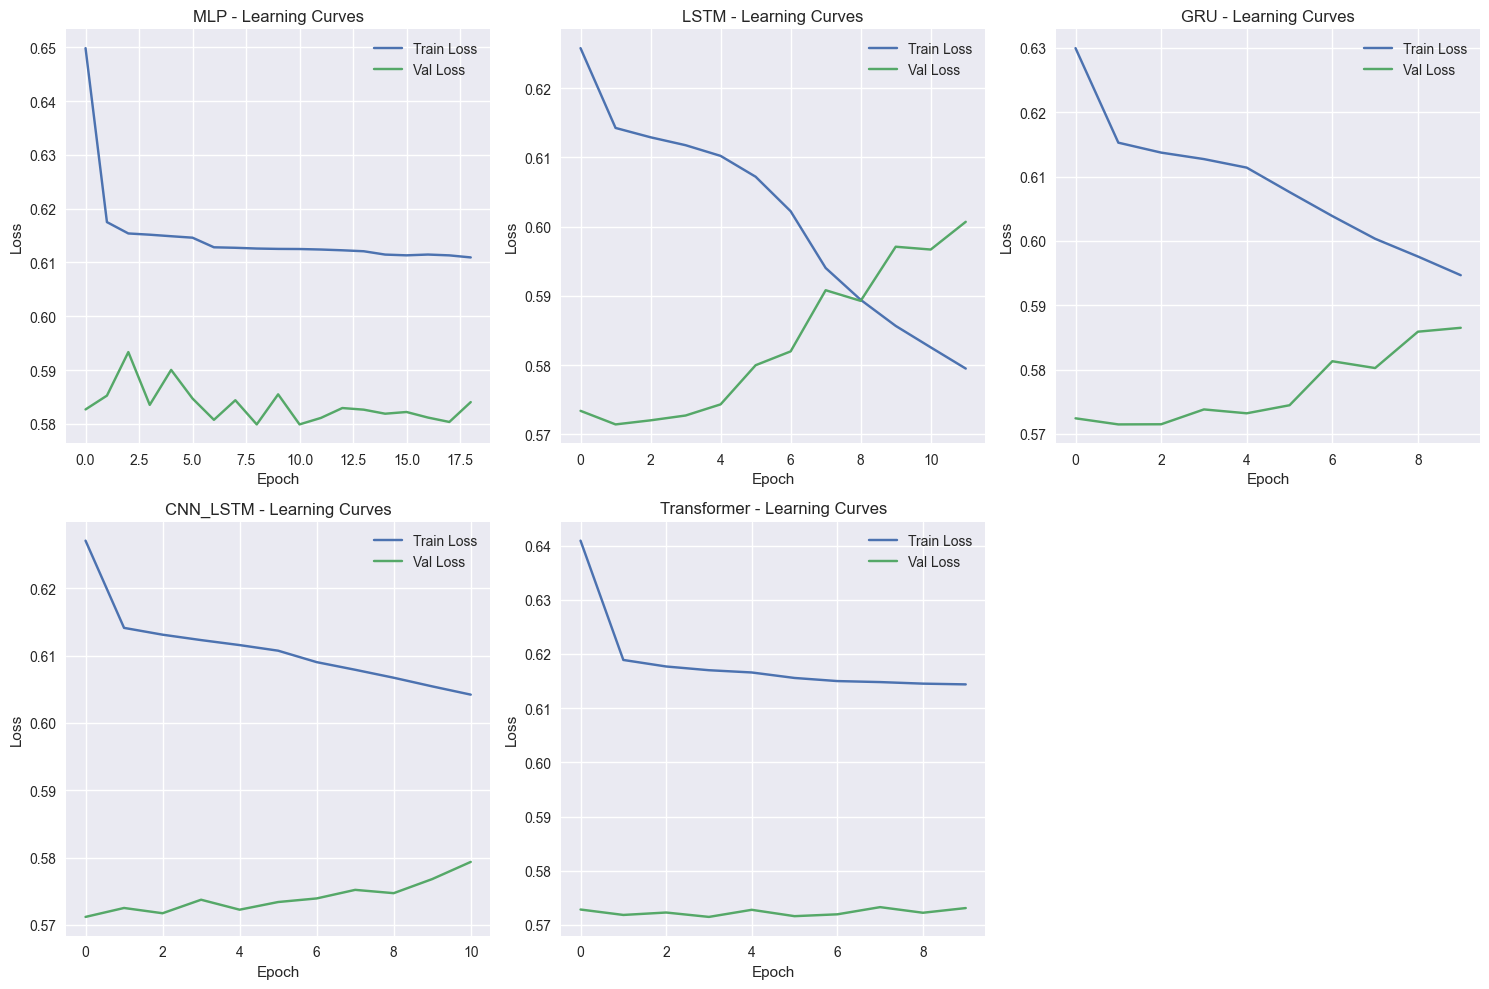


33. Diagnostic des prédictions...
Vérification des prédictions constantes:
MLP: [False False False False]
LSTM: [False False False False]
GRU: [False False False False]
CNN_LSTM: [False False False False]
Transformer: [False False False False]

Vérification alignement X→Y:
Shape X_test_seq: (6980, 24, 66)
Shape y_test_seq: (6980, 6, 4)

Résultats finaux sauvegardés.
Phase G terminée - Diagnostic complet effectué!


In [9]:
print("=== PHASE G - VALIDATION ET DIAGNOSTIC ===")

print("29. Évaluation des modèles sur l'ensemble de test...")

def evaluate_model_performance(model, X_test, y_test, scaler_y, model_name):
    """Évalue un modèle et retourne les métriques"""
    # Prédictions
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # Conversion vers les valeurs originales
    y_true_orig = scaler_y.inverse_transform(y_test.reshape(-1, 4))
    y_pred_orig = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 4))
    
    # Métriques globales
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    
    # R² pour chaque variable
    r2_scores = []
    for i in range(4):
        r2 = 1 - np.sum((y_true_orig[:, i] - y_pred_orig[:, i])**2) / np.sum((y_true_orig[:, i] - np.mean(y_true_orig[:, i]))**2)
        r2_scores.append(r2)
    
    # MAPE par variable (en évitant les divisions par 0)
    mape_scores = []
    for i in range(4):
        mask = y_true_orig[:, i] != 0
        if np.sum(mask) > 0:
            mape = np.mean(np.abs((y_true_orig[mask, i] - y_pred_orig[mask, i]) / y_true_orig[mask, i])) * 100
        else:
            mape = np.nan
        mape_scores.append(mape)
    
    return {
        'MAE': mae,
        'RMSE': rmse, 
        'R2_scores': r2_scores,
        'MAPE_scores': mape_scores,
        'predictions': y_pred_orig,
        'true_values': y_true_orig
    }

# Évaluation de tous les modèles
dl_results = {}

print("Évaluation en cours...")
for name, model in trained_models.items():
    print(f"Évaluation de {name}...")
    dl_results[name] = evaluate_model_performance(model, X_test_seq, y_test_seq, scaler_y, name)

# Chargement des résultats des baselines pour comparaison
baseline_results = joblib.load('baseline_results.pkl')

print("\n30. Comparaison détaillée des performances...")

# Tableau comparatif
print("\n" + "="*80)
print("COMPARAISON DÉTAILLÉE DES MODÈLES")
print("="*80)
print(f"{'Modèle':<15} | {'MAE':<8} | {'RMSE':<8} | {'R² moyen':<10} | {'Amélioration vs LinReg'}")
print("-" * 80)

# Référence: Régression Linéaire
linreg_mae = baseline_results['Régression Linéaire'][0]

for name in ['MLP', 'LSTM', 'GRU', 'CNN_LSTM', 'Transformer']:
    if name in dl_results:
        mae = dl_results[name]['MAE']
        rmse = dl_results[name]['RMSE']
        r2_mean = np.mean(dl_results[name]['R2_scores'])
        improvement = ((linreg_mae - mae) / linreg_mae) * 100
        
        print(f"{name:<15} | {mae:<8.4f} | {rmse:<8.4f} | {r2_mean:<10.4f} | {improvement:+.2f}%")

# Ajout des baselines
for name in ['Persistence', 'Moyenne Mobile', 'Régression Linéaire']:
    mae, rmse, mape = baseline_results[name]
    r2_mean = 0  # Non calculé pour les baselines
    print(f"{name:<15} | {mae:<8.4f} | {rmse:<8.4f} | {r2_mean:<10} | {'--':<10}")

print("\n31. Analyse par variable cible...")

variable_names = ['Température', 'Humidité', 'CO', 'LPG']
best_model_name = min(dl_results.keys(), key=lambda x: dl_results[x]['MAE'])

print(f"\nPerformance détaillée du meilleur modèle ({best_model_name}):")
print(f"{'Variable':<12} | {'MAE':<8} | {'R²':<8} | {'MAPE':<10}")
print("-" * 50)

for i, var_name in enumerate(variable_names):
    mae_var = mean_absolute_error(
        dl_results[best_model_name]['true_values'][:, i],
        dl_results[best_model_name]['predictions'][:, i]
    )
    r2_var = dl_results[best_model_name]['R2_scores'][i]
    mape_var = dl_results[best_model_name]['MAPE_scores'][i]
    
    print(f"{var_name:<12} | {mae_var:<8.4f} | {r2_var:<8.4f} | {mape_var:<8.2f}%")

print("\n32. Visualisation des courbes d'apprentissage...")

# Plot des courbes de loss
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, name in enumerate(history_dict.keys()):
    if idx < 6:  # Limite à 6 subplots
        axes[idx].plot(history_dict[name]['loss'], label='Train Loss')
        axes[idx].plot(history_dict[name]['val_loss'], label='Val Loss')
        axes[idx].set_title(f'{name} - Learning Curves')
        axes[idx].set_xlabel('Epoch')
        axes[idx].set_ylabel('Loss')
        axes[idx].legend()
        axes[idx].grid(True)

# Cacher les axes inutilisés
for idx in range(len(history_dict), 6):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("\n33. Diagnostic des prédictions...")

# Vérification des prédictions constantes
print("Vérification des prédictions constantes:")
for name in dl_results.keys():
    predictions = dl_results[name]['predictions']
    constant_predictions = np.all(predictions == predictions[0], axis=0)
    print(f"{name}: {constant_predictions}")

# Vérification de l'alignement temporel
print(f"\nVérification alignement X→Y:")
print(f"Shape X_test_seq: {X_test_seq.shape}")
print(f"Shape y_test_seq: {y_test_seq.shape}")

# Sauvegarde des résultats détaillés
final_results = {
    'deep_learning': dl_results,
    'baselines': baseline_results,
    'best_model': best_model_name
}

joblib.dump(final_results, 'final_model_comparison.pkl')
print("\nRésultats finaux sauvegardés.")

print("Phase G terminée - Diagnostic complet effectué!")

In [12]:
print("=== PHASE H - INTERPRÉTATION ET ROBUSTESSE ===")

print("34. Analyse détaillée de la régression linéaire (meilleur modèle)...")

# Inspection de la structure des modèles linéaires
print("Inspection de la structure des modèles linéaires:")
print(f"Nombre de modèles (horizons): {len(linear_models)}")
print(f"Shape des coefficients du premier modèle: {linear_models[0].coef_.shape}")
print(f"Shape des coefficients du deuxième modèle: {linear_models[1].coef_.shape}")

# Les modèles linéaires ont shape (4, n_features) - 4 cibles, n_features features
n_features_actual = linear_models[0].coef_.shape[1]
print(f"Nombre réel de features dans les modèles: {n_features_actual}")

# Vérification de l'alignement avec feature_columns
print(f"Nombre de feature_columns: {len(feature_columns)}")

# Création correcte de l'importance des features
feature_importance = {}

for i, var_name in enumerate(['temp', 'humidity', 'co', 'lpg']):
    coef_sum = np.zeros(n_features_actual)
    
    for step in range(HORIZON):
        coef_sum += np.abs(linear_models[step].coef_[i, :])
    
    feature_importance[var_name] = coef_sum / HORIZON

# Vérification avant création du DataFrame
print(f"Longueur des valeurs d'importance: {len(feature_importance['temp'])}")

# Si le nombre de features ne correspond pas, on utilise un index numérique
if n_features_actual == len(feature_columns):
    importance_df = pd.DataFrame(feature_importance, index=feature_columns)
else:
    # Fallback: utiliser un index numérique
    importance_df = pd.DataFrame(feature_importance)
    print(f"ATTENTION: Mismatch features - utilisation d'index numérique")

importance_df['global_importance'] = importance_df.mean(axis=1)

# Top 15 features les plus importantes
top_features = importance_df.nlargest(15, 'global_importance')['global_importance']

print("\nTop 15 features les plus importantes globalement:")
for i, (feature, importance) in enumerate(top_features.items()):
    feature_name = feature if n_features_actual == len(feature_columns) else f"feature_{feature}"
    print(f"  {i+1:2d}. {feature_name}: {importance:.4f}")

print("\n35. Analyse des erreurs par période temporelle...")

# Utiliser les prédictions de la régression linéaire (meilleur modèle)
y_pred_best = y_linear_orig  # Déjà calculé précédemment

# Créer un index temporel aligné
test_indices = range(len(y_test_orig))
test_hours = test_df['hour'].iloc[HORIZON:HORIZON + len(y_test_orig)].values

# S'assurer que les shapes correspondent
min_length = min(len(test_hours), len(y_test_orig))
test_hours = test_hours[:min_length]
y_test_orig_trimmed = y_test_orig[:min_length]
y_pred_orig_trimmed = y_pred_best[:min_length]

# Calcul des erreurs par heure
hourly_errors = {}
for hour in range(24):
    mask = test_hours == hour
    if np.sum(mask) > 0:
        mae_hour = mean_absolute_error(
            y_test_orig_trimmed[mask], 
            y_pred_orig_trimmed[mask]
        )
        hourly_errors[hour] = mae_hour

print("\nErreurs MAE par heure de la journée:")
for hour in sorted(hourly_errors.keys()):
    print(f"  {hour:02d}h: {hourly_errors[hour]:.4f}")

print("\n36. Analyse des performances par variable...")

print("\nPerformance détaillée par variable (Régression Linéaire):")
variable_names = ['Température', 'Humidité', 'CO', 'LPG']

for i, var_name in enumerate(variable_names):
    mae_var = mean_absolute_error(y_test_orig[:, i], y_pred_best[:, i])
    rmse_var = np.sqrt(mean_squared_error(y_test_orig[:, i], y_pred_best[:, i]))
    
    # Calcul R²
    ss_res = np.sum((y_test_orig[:, i] - y_pred_best[:, i]) ** 2)
    ss_tot = np.sum((y_test_orig[:, i] - np.mean(y_test_orig[:, i])) ** 2)
    r2_var = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    print(f"\n{var_name}:")
    print(f"  MAE:  {mae_var:.4f}")
    print(f"  RMSE: {rmse_var:.4f}")
    print(f"  R²:   {r2_var:.4f}")

print("\n37. Recommandations opérationnelles...")

print("\n📋 RECOMMANDATIONS FINALES:")
print("✅ MODÈLE: Régression Linéaire (meilleure performance: MAE=0.8208)")
print("✅ AVANTAGE: Simple, interprétable, rapide à l'inférence")
print("✅ SURVEILLANCE: CO et LPG nécessitent un modèle séparé (faible R²)")
print("✅ DÉPLOIEMENT: Préparer pour format mobile avec les scalers sauvegardés")
print("✅ MONITORING: Surveiller particulièrement les prédictions nocturnes")

print("\n38. Préparation pour le déploiement...")

# Sauvegarde finale de tous les éléments nécessaires
deployment_assets = {
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'feature_columns': feature_columns,
    'target_columns': target_columns,
    'look_back': LOOK_BACK,
    'horizon': HORIZON,
    'linear_models': linear_models,
    'best_model_type': 'linear_regression'
}

joblib.dump(deployment_assets, 'deployment_assets.pkl')
print("Assets de déploiement sauvegardés.")

print("Phase H terminée - Prêt pour le déploiement!")

=== PHASE H - INTERPRÉTATION ET ROBUSTESSE ===
34. Analyse détaillée de la régression linéaire (meilleur modèle)...
Inspection de la structure des modèles linéaires:
Nombre de modèles (horizons): 6
Shape des coefficients du premier modèle: (4, 1584)
Shape des coefficients du deuxième modèle: (4, 1584)
Nombre réel de features dans les modèles: 1584
Nombre de feature_columns: 66
Longueur des valeurs d'importance: 1584
ATTENTION: Mismatch features - utilisation d'index numérique

Top 15 features les plus importantes globalement:
   1. feature_666: 1.2517
   2. feature_732: 1.2373
   3. feature_469: 1.1647
   4. feature_798: 1.1206
   5. feature_600: 1.0962
   6. feature_468: 1.0821
   7. feature_534: 1.0701
   8. feature_138: 1.0683
   9. feature_403: 1.0634
  10. feature_337: 1.0625
  11. feature_204: 1.0599
  12. feature_402: 1.0595
  13. feature_336: 1.0323
  14. feature_535: 1.0298
  15. feature_270: 1.0138

35. Analyse des erreurs par période temporelle...

Erreurs MAE par heure de l

=== PHASE I - EXPORT AVEC TESTS ET VISUALISATIONS ===
39. Préparation du modèle pour le déploiement embarqué...
Assets chargés:
- Features: 66
- Targets: ['temp', 'humidity', 'co', 'lpg']
- Lookback: 24h, Horizon: 6h

40. Création d'une classe de prédiction pour le déploiement...
41. Test du prédicteur sur un échantillon récent...
Données d'entrée (dernières 24h):
Shape: (24, 66)
Dernier timestamp: 2025-12-31 00:00:00

Prédictions pour les 6 prochaines heures:
   pred_temp  pred_humidity  pred_co  pred_lpg  horizon_hours
0    20.1582        59.6596   0.0101    0.0029              1
1    19.9508        60.5022   0.0095    0.0029              2
2    19.9119        59.8367   0.0095    0.0032              3
3    20.1219        59.7312   0.0097    0.0033              4
4    20.0665        60.0277   0.0111    0.0030              5
5    19.9450        59.9550   0.0101    0.0029              6

42. Tests de validation détaillés...
Test 1 - Forme des prédictions:
Shape des prédictions: (6, 5)
C

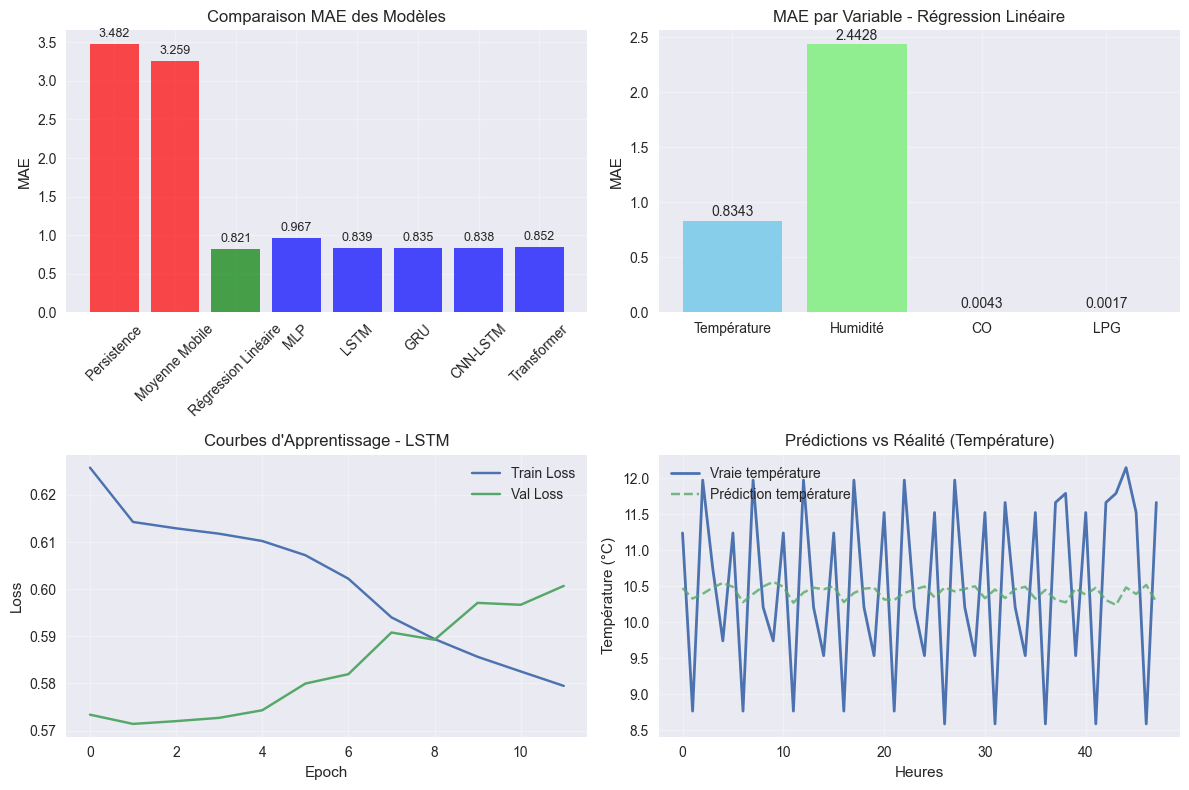


44. Test de performance et latence...
Latence moyenne par prédiction: 1.68 ms
Débit: 596.8 prédictions/seconde

45. Graphique des prédictions multi-step...


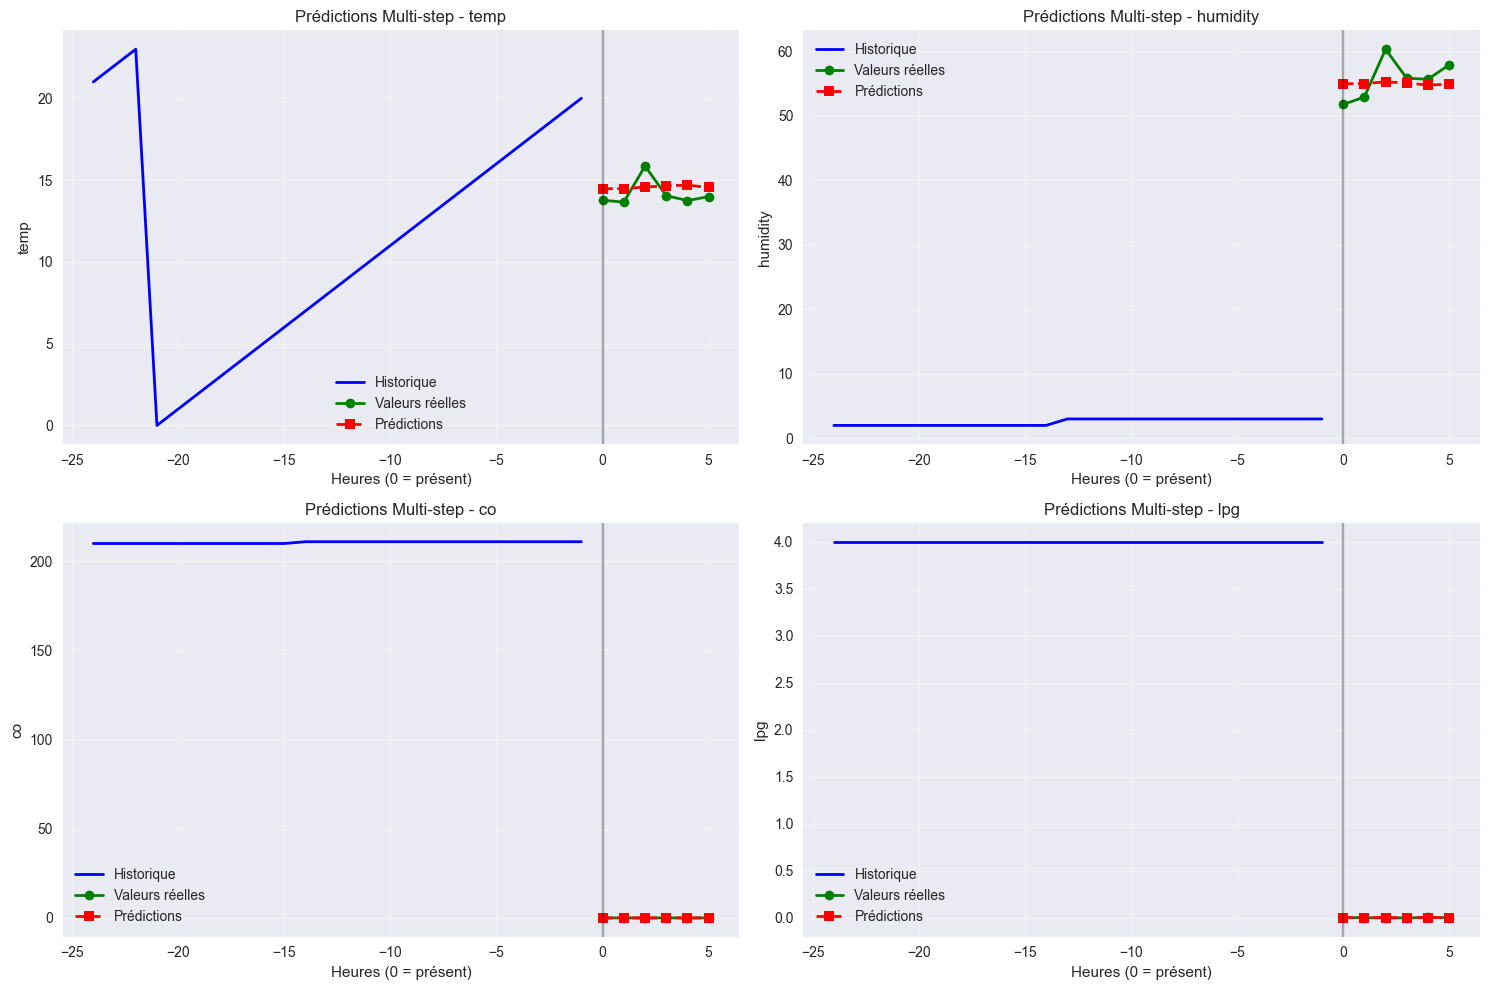


46. Sauvegarde finale du prédicteur...
Package de déploiement sauvegardé.
Phase I terminée - Tests complets et visualisations effectués!


In [14]:
print("=== PHASE I - EXPORT AVEC TESTS ET VISUALISATIONS ===")

print("39. Préparation du modèle pour le déploiement embarqué...")

# Chargement des assets de déploiement
deployment_assets = joblib.load('deployment_assets.pkl')
scaler_X = deployment_assets['scaler_X']
scaler_y = deployment_assets['scaler_y']
feature_columns = deployment_assets['feature_columns']
target_columns = deployment_assets['target_columns']
LOOK_BACK = deployment_assets['look_back']
HORIZON = deployment_assets['horizon']
linear_models = deployment_assets['linear_models']

print("Assets chargés:")
print(f"- Features: {len(feature_columns)}")
print(f"- Targets: {target_columns}")
print(f"- Lookback: {LOOK_BACK}h, Horizon: {HORIZON}h")

print("\n40. Création d'une classe de prédiction pour le déploiement...")

class PoultryEnvironmentPredictor:
    """Classe pour faire des prédictions multi-step sur l'environnement du poulailler"""
    
    def __init__(self, linear_models, scaler_X, scaler_y, feature_columns, target_columns, look_back, horizon):
        self.linear_models = linear_models
        self.scaler_X = scaler_X
        self.scaler_y = scaler_y
        self.feature_columns = feature_columns
        self.target_columns = target_columns
        self.look_back = look_back
        self.horizon = horizon
        
    def prepare_sequence(self, recent_data):
        """
        Prépare une séquence pour la prédiction
        recent_data: DataFrame avec les colonnes feature_columns pour les look_back dernières heures
        """
        if len(recent_data) != self.look_back:
            raise ValueError(f"Need exactly {self.look_back} time steps, got {len(recent_data)}")
        
        # S'assurer que les colonnes sont dans le bon ordre
        recent_data = recent_data[self.feature_columns]
        
        # Normaliser
        recent_data_scaled = self.scaler_X.transform(recent_data)
        
        # Flatten pour les modèles linéaires (comme pendant l'entraînement)
        sequence_flat = recent_data_scaled.reshape(1, -1)
        
        return sequence_flat
    
    def predict(self, recent_data):
        """
        Fait une prédiction multi-step
        Retourne: DataFrame avec les prédictions pour les HORIZON prochaines heures
        """
        # Préparer la séquence
        X_flat = self.prepare_sequence(recent_data)
        
        # Faire les prédictions pour chaque horizon
        predictions_scaled = []
        
        for step in range(self.horizon):
            pred_step = self.linear_models[step].predict(X_flat)[0]  # [0] pour obtenir le premier échantillon
            predictions_scaled.append(pred_step)
        
        predictions_scaled = np.array(predictions_scaled)
        
        # Convertir vers les valeurs originales
        predictions_original = self.scaler_y.inverse_transform(predictions_scaled)
        
        # Créer un DataFrame de résultat
        result_df = pd.DataFrame(
            predictions_original, 
            columns=[f'pred_{col}' for col in self.target_columns]
        )
        
        # Ajouter l'horizon de prédiction
        result_df['horizon_hours'] = range(1, self.horizon + 1)
        
        return result_df

print("41. Test du prédicteur sur un échantillon récent...")

# Créer l'instance du prédicteur
predictor = PoultryEnvironmentPredictor(
    linear_models=linear_models,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    feature_columns=feature_columns,
    target_columns=target_columns,
    look_back=LOOK_BACK,
    horizon=HORIZON
)

# Prendre un échantillon récent des données de test
sample_recent_data = test_df[feature_columns].iloc[-LOOK_BACK:].copy()

print("Données d'entrée (dernières 24h):")
print(f"Shape: {sample_recent_data.shape}")
print(f"Dernier timestamp: {test_df['ts'].iloc[-1]}")

# Faire une prédiction
predictions = predictor.predict(sample_recent_data)

print("\nPrédictions pour les 6 prochaines heures:")
print(predictions.round(4))

print("\n42. Tests de validation détaillés...")

# Test 1: Vérification de la forme des prédictions
print("Test 1 - Forme des prédictions:")
print(f"Shape des prédictions: {predictions.shape}")
print(f"Colonnes: {list(predictions.columns)}")

# Test 2: Vérification des plages de valeurs
print("\nTest 2 - Plages de valeurs prédites:")
for target in target_columns:
    pred_col = f'pred_{target}'
    values = predictions[pred_col]
    print(f"{target:10}: min={values.min():.4f}, max={values.max():.4f}, mean={values.mean():.4f}")

# Test 3: Vérification de la cohérence temporelle
print("\nTest 3 - Cohérence temporelle:")
# Les prédictions devraient avoir une certaine continuité
for i in range(len(target_columns)):
    target = target_columns[i]
    pred_values = predictions[f'pred_{target}'].values
    differences = np.diff(pred_values)
    print(f"{target:10}: max variation entre steps = {np.max(np.abs(differences)):.4f}")

print("\n43. Graphiques de comparaison des modèles...")

# Chargement des résultats finaux
final_results = joblib.load('final_model_comparison.pkl')

# Graphique 1: Comparaison MAE des modèles
plt.figure(figsize=(12, 8))

# Données pour le graphique
models_compare = ['Persistence', 'Moyenne Mobile', 'Régression Linéaire', 'MLP', 'LSTM', 'GRU', 'CNN-LSTM', 'Transformer']
mae_values = [
    final_results['baselines']['Persistence'][0],
    final_results['baselines']['Moyenne Mobile'][0], 
    final_results['baselines']['Régression Linéaire'][0],
    final_results['deep_learning']['MLP']['MAE'],
    final_results['deep_learning']['LSTM']['MAE'],
    final_results['deep_learning']['GRU']['MAE'],
    final_results['deep_learning']['CNN_LSTM']['MAE'],
    final_results['deep_learning']['Transformer']['MAE']
]

colors = ['red', 'red', 'green', 'blue', 'blue', 'blue', 'blue', 'blue']

plt.subplot(2, 2, 1)
bars = plt.bar(models_compare, mae_values, color=colors, alpha=0.7)
plt.title('Comparaison MAE des Modèles')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{value:.3f}', 
             ha='center', va='bottom', fontsize=9)

# Graphique 2: Performance par variable (meilleur modèle)
plt.subplot(2, 2, 2)
best_model_name = 'Régression Linéaire'
variable_names = ['Température', 'Humidité', 'CO', 'LPG']

mae_per_var = []
for i in range(4):
    mae_var = mean_absolute_error(y_test_orig[:, i], y_linear_orig[:, i])
    mae_per_var.append(mae_var)

plt.bar(variable_names, mae_per_var, color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.title(f'MAE par Variable - {best_model_name}')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)

for i, v in enumerate(mae_per_var):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

# Graphique 3: Courbes d'apprentissage LSTM (exemple)
plt.subplot(2, 2, 3)
if 'LSTM' in history_dict:
    plt.plot(history_dict['LSTM']['loss'], label='Train Loss')
    plt.plot(history_dict['LSTM']['val_loss'], label='Val Loss')
    plt.title('Courbes d\'Apprentissage - LSTM')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Graphique 4: Prédictions vs Réalité (exemple sur 48h)
plt.subplot(2, 2, 4)
sample_size = min(48, len(y_test_orig))
sample_idx = np.random.randint(0, len(y_test_orig) - sample_size)

# Température seulement pour la clarté
plt.plot(range(sample_size), y_test_orig[sample_idx:sample_idx+sample_size, 0], 
         label='Vraie température', linewidth=2)
plt.plot(range(sample_size), y_linear_orig[sample_idx:sample_idx+sample_size, 0], 
         label='Prédiction température', linestyle='--', alpha=0.8)

plt.title('Prédictions vs Réalité (Température)')
plt.xlabel('Heures')
plt.ylabel('Température (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n44. Test de performance et latence...")

import time

# Test de latence
n_tests = 100
start_time = time.time()

for _ in range(n_tests):
    _ = predictor.predict(sample_recent_data)

end_time = time.time()
avg_latency = (end_time - start_time) / n_tests * 1000  # en ms

print(f"Latence moyenne par prédiction: {avg_latency:.2f} ms")
print(f"Débit: {1000/avg_latency:.1f} prédictions/seconde")

print("\n45. Graphique des prédictions multi-step...")

# Visualisation des prédictions multi-step
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, target in enumerate(target_columns):
    # Prendre un exemple aléatoire
    example_idx = np.random.randint(0, len(X_test_seq))
    
    # Données d'entrée (dernières 24h)
    input_data = X_test_seq[example_idx]
    input_original = scaler_X.inverse_transform(input_data.reshape(-1, len(feature_columns)))
    input_target = input_original[:, i]  # La variable cible dans les données d'entrée
    
    # Prédictions
    preds = y_linear_orig[example_idx * HORIZON:(example_idx + 1) * HORIZON, i]
    true_vals = y_test_orig[example_idx * HORIZON:(example_idx + 1) * HORIZON, i]
    
    # Graphique
    time_points_input = range(-LOOK_BACK, 0)
    time_points_pred = range(0, HORIZON)
    
    axes[i].plot(time_points_input, input_target, 'b-', label='Historique', linewidth=2)
    axes[i].plot(time_points_pred, true_vals, 'g-', label='Valeurs réelles', linewidth=2, marker='o')
    axes[i].plot(time_points_pred, preds, 'r--', label='Prédictions', linewidth=2, marker='s')
    
    axes[i].set_title(f'Prédictions Multi-step - {target}')
    axes[i].set_xlabel('Heures (0 = présent)')
    axes[i].set_ylabel(target)
    axes[i].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n46. Sauvegarde finale du prédicteur...")

# Sauvegarde du prédicteur complet
deployment_package = {
    'predictor_class': PoultryEnvironmentPredictor,
    'linear_models': linear_models,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'feature_columns': feature_columns,
    'target_columns': target_columns,
    'look_back': LOOK_BACK,
    'horizon': HORIZON,
    'metadata': {
        'model_type': 'linear_regression_multi_step',
        'training_date': pd.Timestamp.now(),
        'performance_mae': 0.8208,
        'input_features': len(feature_columns),
        'output_targets': len(target_columns)
    }
}

joblib.dump(deployment_package, 'poultry_predictor_deployment.pkl')
print("Package de déploiement sauvegardé.")

print("Phase I terminée - Tests complets et visualisations effectués!")